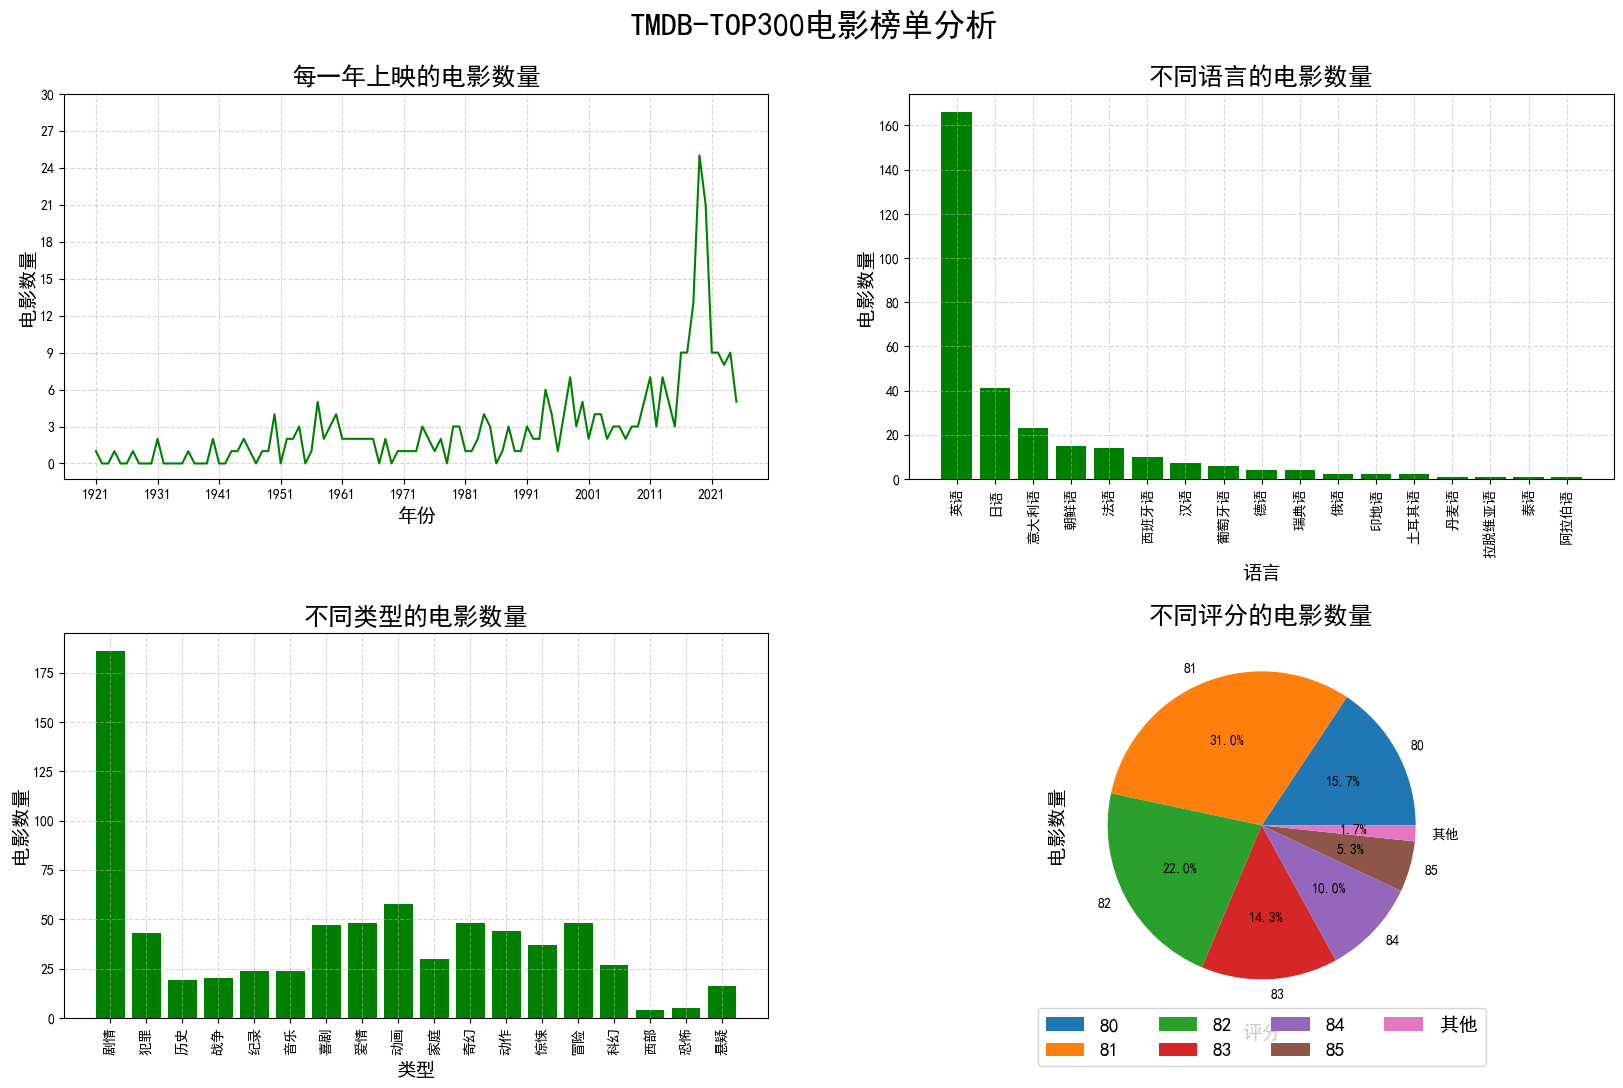

In [6]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig,axes = plt.subplots(2,2,figsize = (20,12))
fig.suptitle('TMDB-TOP300电影榜单分析',fontsize = 23,x = 0.5,y = 0.95) #设置主标题 字体大小,x 垂直方位,y 水平方位
fig.subplots_adjust(wspace = 0.2,hspace = 0.4) #设置子图间距  wspace 水平间距 hspace 垂直间距

#获取子图
axes1:Axes = axes[0,0]
axes2:Axes = axes[0,1]
axes3:Axes = axes[1,0]
axes4:Axes = axes[1,1]

#加载数据
#int64:整数数字(不支持空值)

#Int64:整数数字(支持空值)

#float64:浮点数数字(支持空值)

data = pd.read_csv('素材/movies.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})
data



#1. 需求一:统计TOP300的电影中,每一年上映的电影数量的变化  折线图

#1.1 缺失值 异常值处理
data.isnull().sum() #查看缺失值数量
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

#1.2 统计每一年上映的电影数量
year_count = data.groupby('年份')['电影名'].count()

#1.3 组装数据

# x轴数据
max_year = year_count.index.max()
min_year = year_count.index.min()
x = [i for i in range(min_year,max_year+1)]


# y轴数据
y = [int(year_count.get(i,0)) for i in x]#获取每一年上映的电影数量,如果年份不存在,则返回0

#1.4 绘制折线图
axes1.plot(x,y,color = 'green') #绘制折线图
axes1.set_title('每一年上映的电影数量',fontsize = 18) #设置子图标题 字体大小
axes1.set_xlabel('年份',fontsize = 14) #设置x轴标签 字体大小
axes1.set_ylabel('电影数量',fontsize = 14) #设置y轴标签 字体大小

axes1.set_xticks(x[::10]) #设置x轴刻度间隔
y_tick = [i for i in range(0,31,3)]
axes1.set_yticks(y_tick) #设置y轴刻度间隔
axes1.grid(linestyle = '--',alpha = 0.5) #添加网格线



#2. 需求二: 统计对比不同语言的电影数量  (柱状图)

#2.1 获取不同语言对应电影的数量
lang_count = data.groupby('语言')['语言'].count().sort_values(ascending = False)


x_language = lang_count.index
y_language = lang_count.values

#2.2 绘制柱状图
axes2.bar(x_language,y_language,color = 'green')
axes2.set_title('不同语言的电影数量',fontsize = 18)
axes2.set_xlabel('语言',fontsize = 14)#设置x轴标签 字体大小
axes2.set_ylabel('电影数量',fontsize = 14)#设置y轴标签 字体大小
axes2.grid(linestyle = '--',alpha = 0.5) #添加网格线
axes2.tick_params(axis = 'x',rotation = 90) #设置x轴刻度标签 旋转角度


#3. 需求三: 统计对比不同类型的电影数量  (柱状图)
#3.1 获取不同类型对应电影的数量
type_count = {}
for types in data['类型'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1
            

x_types = type_count.keys()
y_values = type_count.values()

#3.2 绘制柱状图
axes3.bar(x_types,y_values,color = 'green')
axes3.set_title('不同类型的电影数量',fontsize = 18)
axes3.set_xlabel('类型',fontsize = 14)#设置x轴标签 字体大小
axes3.set_ylabel('电影数量',fontsize = 14)#设置y轴标签 字体大小
axes3.grid(linestyle = '--',alpha = 0.5) #添加网格线
axes3.tick_params(axis = 'x',rotation = 90) #设置x轴刻度标签 字体大小


#4. 需求四: 统计不同评分的电影数量  (饼状图)
#4.1 获取不同评分对应电影的数量
score_count = data.groupby('评分')['评分'].count()

#合并小数据(比例< 2%)---->其他
total = score_count.sum()
large_scores = score_count.loc[score_count >= total*0.02] #获取评分大于等于2%的电影数量
small_scores = score_count.loc[score_count < total*0.02] #获取评分小于2%的电影数量

if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()
    




scores = large_scores.index #评分列表
scores_values =large_scores.values #电影数量


#4.2 绘制饼状图
axes4.pie(scores_values,labels = scores,autopct = '%1.1f%%',startangle = 0) #startangle 起始角度 0度
axes4.set_title('不同评分的电影数量',fontsize = 18)
axes4.legend(loc = 'lower center',ncol = 4,bbox_to_anchor = (0.5,-0.15),fontsize = 14) #设置图例字体大小
axes4.set_xlabel('评分',fontsize = 14)#设置x轴标签 字体大小
axes4.set_ylabel('电影数量',fontsize = 14)#设置y轴标签 字体大小
axes4.grid(linestyle = '--',alpha = 0.5) #添加网格线
axes4.tick_params(axis = 'x',rotation = 90) #设置x轴刻度标签 字体大小






